# Module 06 — Visa & Friction Analysis (NYC → Dubai)

**Data Sources:** Google Trends (#3) + Aviation Edge (#4) + `VISA_POLICY_EVENTS`

**Business Questions:**
1. How did visa-policy changes and external shocks (COVID) affect NYC→Dubai demand?
2. How quickly did demand recover after each shock?
3. Does the "Dubai visa" search keyword spike around policy changes?
4. What OTA playbook should we run for each shock severity level?


In [14]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
from textwrap import fill

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

print("Setup complete")


Setup complete


In [17]:
from config.settings import (
    VISA_POLICY_EVENTS,
    GOOGLE_CLOUD_API_KEY,
    AVIATION_EDGE_API_KEY,
)

from src.data_collection.google_trends import (
    generate_synthetic_trends,
    fetch_google_trends,
    detect_search_spikes,
    extract_seasonal_patterns,
    resample_trends_monthly,
)

from src.data_collection.aviation_edge import (
    generate_synthetic_monthly_capacity,
)

from src.analysis.policy_impact_analyzer import (
    build_policy_timeline,
    add_policy_regimes,
    compute_composite_demand_index,
    pre_post_impact,
    estimate_recovery_time,
    friction_demand_correlation,
    regime_summary_stats,
    classify_shock_severity,
    compute_demand_momentum,
    align_visa_spikes_to_events,
    generate_disruption_playbook,
    yoy_comparison,
)

print("Imports loaded")


ImportError: cannot import name 'estimate_recovery_time' from 'src.analysis.policy_impact_analyzer' (c:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\src\analysis\policy_impact_analyzer.py)

In [18]:
# ── Google Trends ─────────────────────────────────────────
trends_raw = None
if GOOGLE_CLOUD_API_KEY:
    try:
        trends_raw = fetch_google_trends()
        if trends_raw is None or trends_raw.empty:
            raise ValueError("Empty trends response")
        print(f"Real Google Trends loaded: {trends_raw.shape}")
    except Exception as e:
        print(f"Trends API failed ({e}) -> synthetic fallback")
        trends_raw = generate_synthetic_trends()
else:
    print("No GOOGLE_CLOUD_API_KEY -> synthetic trends")
    trends_raw = generate_synthetic_trends()

# ── Aviation Edge ─────────────────────────────────────────
capacity_raw = None
if AVIATION_EDGE_API_KEY:
    try:
        capacity_raw = generate_synthetic_monthly_capacity()
        print(f"Aviation capacity loaded: {capacity_raw.shape}")
    except Exception as e:
        print(f"Aviation data failed ({e}) -> synthetic fallback")
        capacity_raw = generate_synthetic_monthly_capacity()
else:
    print("No AVIATION_EDGE_API_KEY -> synthetic capacity")
    capacity_raw = generate_synthetic_monthly_capacity()

print(f"\nTrends shape : {trends_raw.shape}")
print(f"Capacity shape: {capacity_raw.shape}")


Fetching Google Trends for 5 keywords...
  Geo: US-NY  |  Timeframe: 2019-01-01 2025-12-31
  Batch 1: ['NYC to Dubai flights', 'Dubai hotels', 'Dubai visa', 'Dubai tourism', 'cheap flights to Dubai']
    ✗ Error: Retry.__init__() got an unexpected keyword argument 'method_whitelist'

⚠️  No data retrieved.
Trends API failed (Empty trends response) -> synthetic fallback
Generated synthetic Trends: 365 weeks × 5 keywords
Generated monthly capacity: 84 months (2019-01 → 2025-12)
Aviation capacity loaded: (84, 8)

Trends shape : (365, 5)
Capacity shape: (84, 8)


In [19]:
print("=== Trends (weekly, first 5 rows) ===")
display(trends_raw.head())
print("\n=== Capacity (monthly, first 5 rows) ===")
display(capacity_raw.head())


=== Trends (weekly, first 5 rows) ===


,NYC to Dubai flights,Dubai hotels,Dubai visa,Dubai tourism,cheap flights to Dubai
date,,,,,
2019-01-06,48,63,33,52,39
2019-01-13,45,66,30,52,35
2019-01-20,48,65,34,42,38
2019-01-27,52,66,27,56,36
2019-02-03,38,50,31,46,31



=== Capacity (monthly, first 5 rows) ===


,DATE,YEAR,MONTH,MONTHLY_FLIGHTS,MONTHLY_SEATS,LOAD_FACTOR,EST_PASSENGERS,AVG_DAILY_FLIGHTS
0,2019-01-01,2019,1,164,62351,0.893,55654,5.3
1,2019-02-01,2019,2,157,59747,0.840,50175,5.6
2,2019-03-01,2019,3,139,52821,0.773,40851,4.5
3,2019-04-01,2019,4,110,42026,0.880,36979,3.7
4,2019-05-01,2019,5,127,48549,0.856,41568,4.1


In [20]:
policy_df = build_policy_timeline(VISA_POLICY_EVENTS)
display(policy_df)


,date,event,friction_score,direction
0,2014-01-01,Visa-on-arrival for US citizens (30-day free),2,reduced
1,2017-06-01,6-month multiple entry visa option,1,reduced
2,2020-03-15,COVID-19 travel ban,10,increased
3,2020-07-07,UAE reopened with PCR test requirement,7,reduced
4,2022-02-26,All COVID entry requirements removed,1,reduced
5,2023-01-01,"UAE visa-free expanded, streamlined e-gate",1,reduced


In [21]:
# Resample weekly trends to monthly
trends_monthly = resample_trends_monthly(trends_raw)
trends_monthly = trends_monthly.reset_index()
trends_monthly.rename(columns={"DATE": "date"}, inplace=True)
if "date" not in trends_monthly.columns:
    trends_monthly.rename(columns={trends_monthly.columns[0]: "date"}, inplace=True)
trends_monthly["date"] = pd.to_datetime(trends_monthly["date"])

# Prepare capacity
capacity = capacity_raw.copy()
capacity["date"] = pd.to_datetime(capacity["DATE"])

# Merge on month
merged = pd.merge(
    trends_monthly,
    capacity[["date", "MONTHLY_FLIGHTS", "MONTHLY_SEATS", "EST_PASSENGERS", "LOAD_FACTOR"]],
    on="date",
    how="inner",
)

# Composite demand index (60% trends, 40% flights)
merged = compute_composite_demand_index(
    merged,
    trend_col="Dubai tourism",
    flights_col="EST_PASSENGERS",
)

# Annotate with policy regimes
merged = add_policy_regimes(merged, policy_df, date_col="date")

print(f"Merged dataset: {merged.shape[0]} months x {merged.shape[1]} cols")
display(merged[["date", "Dubai tourism", "Dubai visa", "EST_PASSENGERS",
                "demand_index", "friction_score", "policy_event"]].head(10))


Merged dataset: 84 months x 16 cols


,date,Dubai tourism,Dubai visa,EST_PASSENGERS,demand_index,friction_score,policy_event
0,2019-01-01,50.5,31.0,55654,1.009656,1.0,6-month multiple entry visa option
1,2019-02-01,44.8,29.5,50175,0.639118,1.0,6-month multiple entry visa option
2,2019-03-01,37.4,23.2,40851,0.102112,1.0,6-month multiple entry visa option
3,2019-04-01,35.5,21.2,36979,-0.073176,1.0,6-month multiple entry visa option
4,2019-05-01,32.2,16.0,41568,-0.091268,1.0,6-month multiple entry visa option
5,2019-06-01,32.6,17.8,30590,-0.352847,1.0,6-month multiple entry visa option
6,2019-07-01,27.0,15.2,32918,-0.521724,1.0,6-month multiple entry visa option
7,2019-08-01,23.8,18.0,28996,-0.751159,1.0,6-month multiple entry visa option
8,2019-09-01,35.2,20.8,37792,-0.064803,1.0,6-month multiple entry visa option
9,2019-10-01,39.0,25.8,45793,0.292277,1.0,6-month multiple entry visa option


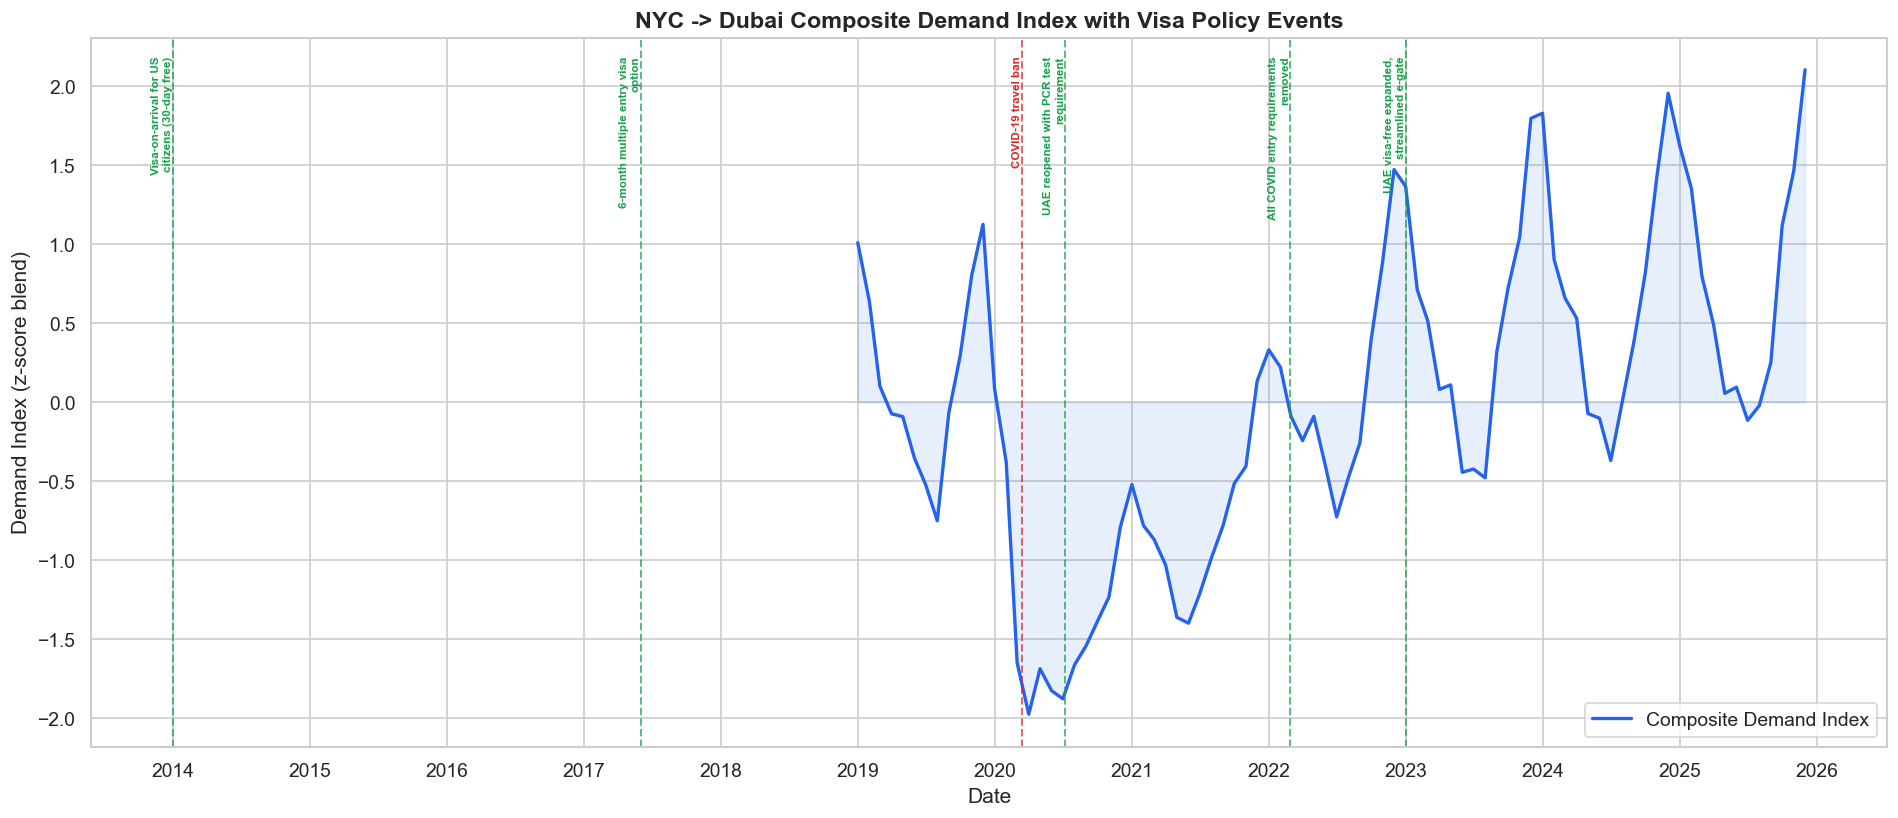

In [22]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(merged["date"], merged["demand_index"], color="#2563eb",
        linewidth=2, label="Composite Demand Index")
ax.fill_between(merged["date"], merged["demand_index"], alpha=0.10, color="#2563eb")

# Mark policy events
colors = {"reduced": "#16a34a", "increased": "#dc2626"}
for _, ev in policy_df.iterrows():
    c = colors.get(ev["direction"], "gray")
    ax.axvline(ev["date"], color=c, linestyle="--", alpha=0.7, linewidth=1.2)
    ax.annotate(
        fill(ev["event"], 28),
        xy=(ev["date"], ax.get_ylim()[1] * 0.95),
        fontsize=7, rotation=90, va="top", ha="right",
        color=c, fontweight="bold",
    )

ax.set_title("NYC -> Dubai Composite Demand Index with Visa Policy Events", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Demand Index (z-score blend)")
ax.legend(loc="lower right")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


In [23]:
impact_results = []
for _, ev in policy_df.iterrows():
    result = pre_post_impact(
        merged, event_date=str(ev["date"].date()),
        metric_col="demand_index", window_days=90, date_col="date",
    )
    result["event"] = ev["event"]
    result["direction"] = ev["direction"]
    result["friction_score"] = ev["friction_score"]
    result["severity"] = classify_shock_severity(result["pct_change"])
    impact_results.append(result)

impact_df = pd.DataFrame(impact_results)
display(impact_df[["event_date", "event", "direction", "friction_score",
                   "pre_mean", "post_mean", "pct_change", "severity"]])


NameError: name 'classify_shock_severity' is not defined

NameError: name 'impact_df' is not defined

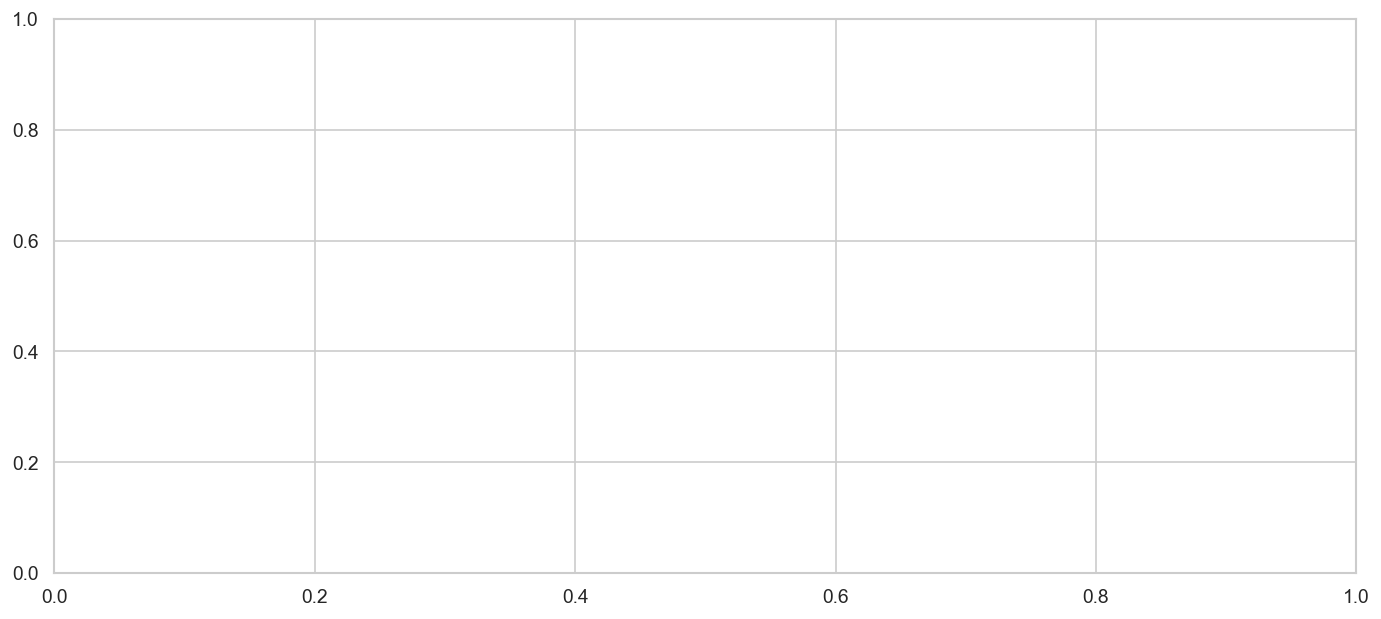

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    [fill(e, 35) for e in impact_df["event"]],
    impact_df["pct_change"],
    color=["#dc2626" if v < 0 else "#16a34a" for v in impact_df["pct_change"]],
    edgecolor="white", linewidth=0.5,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Demand Index Change (%)")
ax.set_title("Pre -> Post Demand Impact by Policy Event", fontsize=13, fontweight="bold")

for bar, val in zip(bars, impact_df["pct_change"]):
    if not np.isnan(val):
        ax.text(bar.get_width() + (1 if val >= 0 else -1), bar.get_y() + bar.get_height() / 2,
                f"{val:+.1f}%", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


In [25]:
recovery_results = []
for _, ev in policy_df.iterrows():
    rec = estimate_recovery_time(
        merged, event_date=str(ev["date"].date()),
        metric_col="demand_index", baseline_window_days=90,
        threshold_pct=0.90, date_col="date",
    )
    rec["event"] = ev["event"]
    rec["friction_score"] = ev["friction_score"]
    recovery_results.append(rec)

recovery_df = pd.DataFrame(recovery_results)
display(recovery_df[["event_date", "event", "friction_score",
                     "baseline", "target_90pct", "recovery_days", "recovery_months"]])


NameError: name 'estimate_recovery_time' is not defined

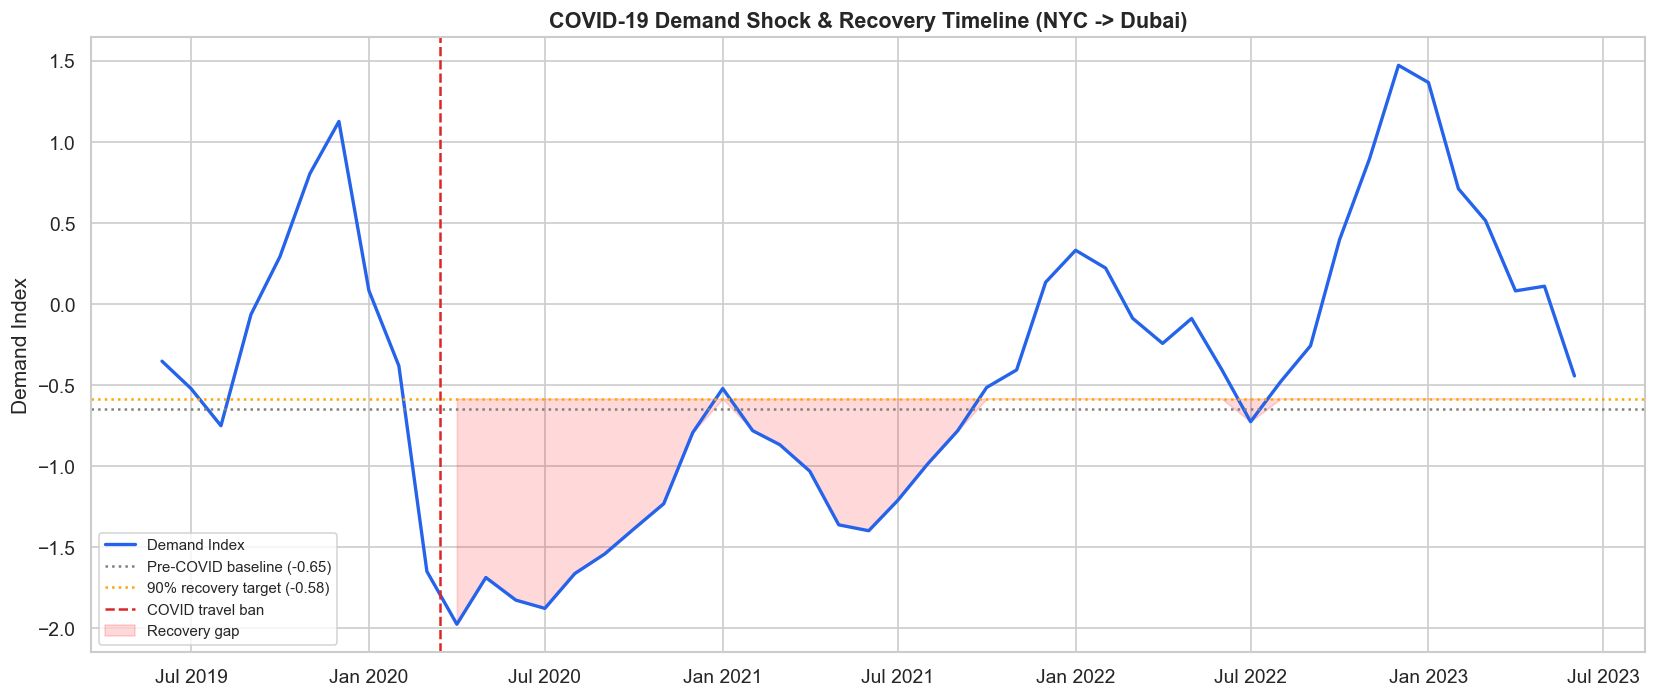

In [26]:
covid_date = pd.to_datetime("2020-03-15")
window = merged[(merged["date"] >= "2019-06-01") & (merged["date"] <= "2023-06-01")].copy()

pre_covid = merged[(merged["date"] < covid_date) &
                   (merged["date"] >= covid_date - pd.Timedelta(days=90))]
baseline = pre_covid["demand_index"].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(window["date"], window["demand_index"], color="#2563eb", linewidth=2, label="Demand Index")
ax.axhline(baseline, color="gray", linestyle=":", label=f"Pre-COVID baseline ({baseline:.2f})")
ax.axhline(baseline * 0.9, color="orange", linestyle=":", label=f"90% recovery target ({baseline*0.9:.2f})")
ax.axvline(covid_date, color="#dc2626", linestyle="--", linewidth=1.5, label="COVID travel ban")

post_covid = window[window["date"] >= covid_date]
ax.fill_between(post_covid["date"],
                post_covid["demand_index"].clip(upper=baseline * 0.9),
                baseline * 0.9,
                alpha=0.15, color="red", label="Recovery gap")

ax.set_title("COVID-19 Demand Shock & Recovery Timeline (NYC -> Dubai)", fontsize=13, fontweight="bold")
ax.set_ylabel("Demand Index")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()


In [27]:
corr = friction_demand_correlation(merged)
print(f"Pearson  r = {corr['pearson']}")
print(f"Spearman p = {corr['spearman']}")
print(f"N obs      = {corr['n']}")


NameError: name 'friction_demand_correlation' is not defined

NameError: name 'corr' is not defined

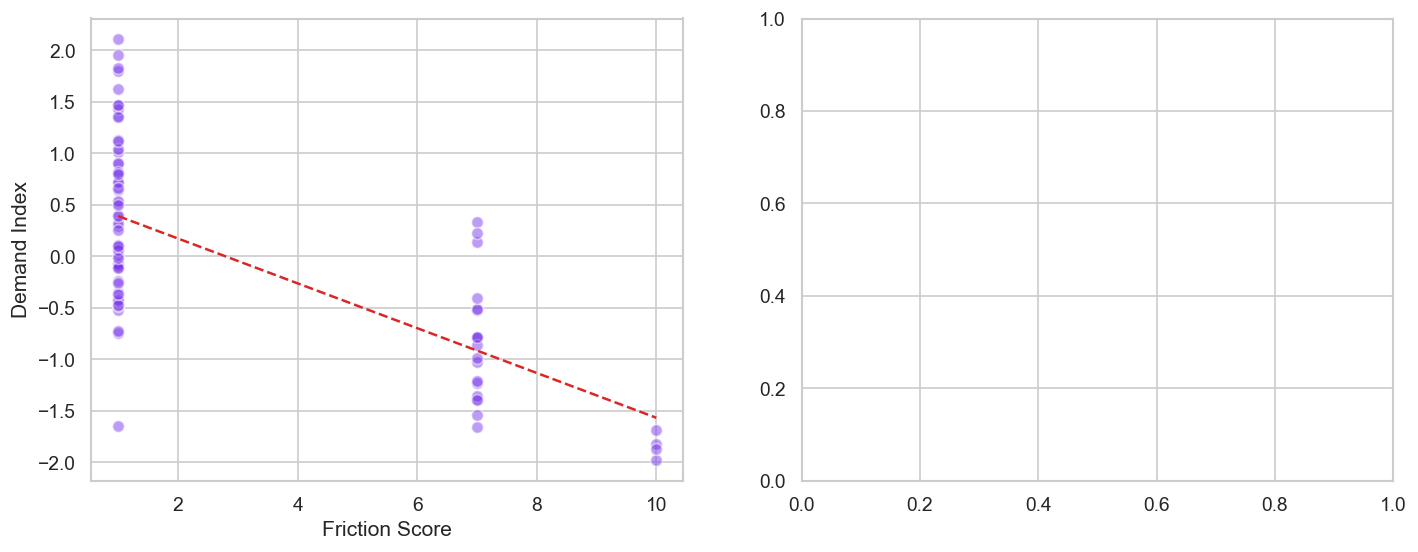

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: friction vs demand
ax = axes[0]
valid = merged.dropna(subset=["friction_score", "demand_index"])
ax.scatter(valid["friction_score"], valid["demand_index"],
           alpha=0.5, color="#7c3aed", edgecolor="white", s=50)
z = np.polyfit(valid["friction_score"], valid["demand_index"], 1)
p = np.poly1d(z)
x_line = np.linspace(valid["friction_score"].min(), valid["friction_score"].max(), 50)
ax.plot(x_line, p(x_line), "--", color="#dc2626", linewidth=1.5)
ax.set_xlabel("Friction Score")
ax.set_ylabel("Demand Index")
ax.set_title(f"Friction vs Demand (r={corr['pearson']})")

# Box plot: demand by friction level
ax = axes[1]
valid["friction_bucket"] = pd.cut(valid["friction_score"], bins=[0, 2, 5, 8, 10],
                                   labels=["Low (1-2)", "Med (3-5)", "High (6-8)", "Extreme (9-10)"])
valid.boxplot(column="demand_index", by="friction_bucket", ax=ax)
ax.set_title("Demand Index by Friction Bucket")
ax.set_xlabel("Friction Bucket")
ax.set_ylabel("Demand Index")
plt.suptitle("")

plt.tight_layout()
plt.show()


In [29]:
regime_stats = regime_summary_stats(merged)
display(regime_stats)


NameError: name 'regime_summary_stats' is not defined

NameError: name 'regime_stats' is not defined

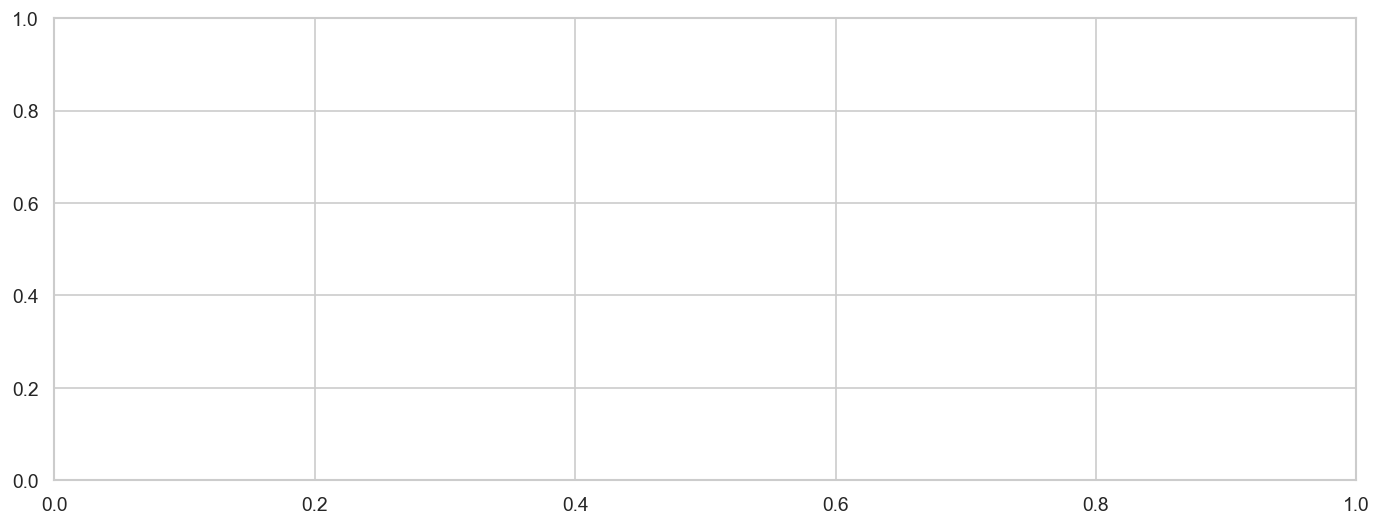

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
regime_stats_sorted = regime_stats.sort_values("demand_mean")
colors = ["#dc2626" if v < 0 else "#16a34a" for v in regime_stats_sorted["demand_mean"]]
ax.barh([fill(r, 30) for r in regime_stats_sorted["regime"]], regime_stats_sorted["demand_mean"],
        xerr=regime_stats_sorted["demand_std"], color=colors, edgecolor="white", capsize=4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean Demand Index")
ax.set_title("Average Demand by Policy Regime", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [31]:
visa_spikes = detect_search_spikes(trends_raw, keyword="Dubai visa", threshold_std=1.5)
if not visa_spikes.empty:
    print(f"Found {len(visa_spikes)} spikes in 'Dubai visa' searches")
    display(visa_spikes.head(10))
else:
    print("No spikes detected at 1.5 sigma threshold")


Found 48 spikes for 'Dubai visa'
Found 48 spikes in 'Dubai visa' searches


,NYC to Dubai flights,Dubai hotels,Dubai visa,Dubai tourism,cheap flights to Dubai,ROLLING_MEAN,SPIKE_MAGNITUDE,KEYWORD
date,,,,,,,,
2019-06-30,25,30,25,33,24,18.083333,1.382488,Dubai visa
2019-08-18,23,41,24,22,17,17.166667,1.398058,Dubai visa
2019-09-22,20,40,25,40,28,18.250000,1.369863,Dubai visa
2019-10-06,34,45,29,37,31,19.500000,1.487179,Dubai visa
2019-11-03,39,58,32,49,34,23.250000,1.376344,Dubai visa
2019-12-01,53,61,34,55,45,26.166667,1.299363,Dubai visa
2019-12-08,50,78,35,57,42,27.416667,1.276596,Dubai visa
2019-12-15,42,72,37,55,47,28.416667,1.302053,Dubai visa
2020-07-05,11,15,12,12,5,4.500000,2.666667,Dubai visa


In [32]:
aligned = align_visa_spikes_to_events(trends_raw, policy_df,
                                       keyword="Dubai visa", proximity_days=45)
if not aligned.empty:
    print(f"{len(aligned)} spike(s) coincided with policy events (+-45 days):")
    display(aligned)
else:
    print("No spikes aligned with policy events within +-45 days")


NameError: name 'align_visa_spikes_to_events' is not defined

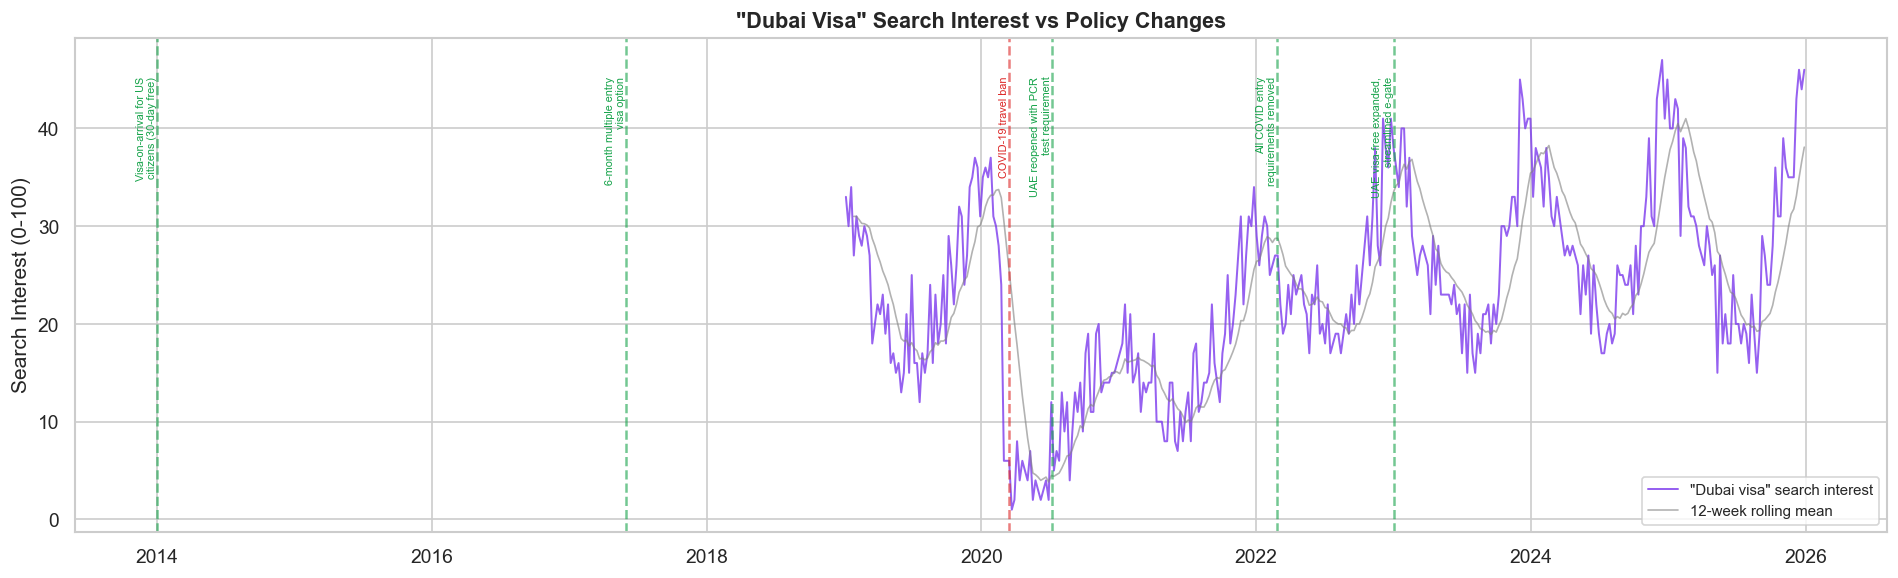

In [33]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(trends_raw.index, trends_raw["Dubai visa"], color="#7c3aed",
        linewidth=1.2, alpha=0.8, label='"Dubai visa" search interest')

rmean = trends_raw["Dubai visa"].rolling(12, min_periods=4).mean()
ax.plot(trends_raw.index, rmean, color="gray", linestyle="-", linewidth=1, alpha=0.6, label="12-week rolling mean")

for _, ev in policy_df.iterrows():
    c = "#dc2626" if ev["direction"] == "increased" else "#16a34a"
    ax.axvline(ev["date"], color=c, linestyle="--", alpha=0.6)
    ax.annotate(fill(ev["event"], 25), xy=(ev["date"], ax.get_ylim()[1] * 0.92),
               fontsize=6.5, rotation=90, va="top", ha="right", color=c)

ax.set_title('"Dubai Visa" Search Interest vs Policy Changes', fontsize=13, fontweight="bold")
ax.set_ylabel("Search Interest (0-100)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [34]:
momentum = compute_demand_momentum(merged, date_col="date")

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(momentum["date"], momentum["demand_index"], color="#2563eb", linewidth=1.5)
axes[0].set_ylabel("Demand Index")
axes[0].set_title("Demand Index & Month-over-Month Momentum", fontsize=13, fontweight="bold")

colors = ["#16a34a" if v >= 0 else "#dc2626" for v in momentum["demand_mom"].fillna(0)]
axes[1].bar(momentum["date"], momentum["demand_mom"].fillna(0), color=colors, width=25)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("MoM Change")
axes[1].set_xlabel("Date")

for ax in axes:
    for _, ev in policy_df.iterrows():
        c = "#dc2626" if ev["direction"] == "increased" else "#16a34a"
        ax.axvline(ev["date"], color=c, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()


NameError: name 'compute_demand_momentum' is not defined

In [35]:
yoy = yoy_comparison(merged, date_col="date")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(yoy, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "YoY Change (%)"})
ax.set_title("Year-over-Year Demand Change by Month (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_yticklabels(month_labels, rotation=0)
plt.tight_layout()
plt.show()


NameError: name 'yoy_comparison' is not defined

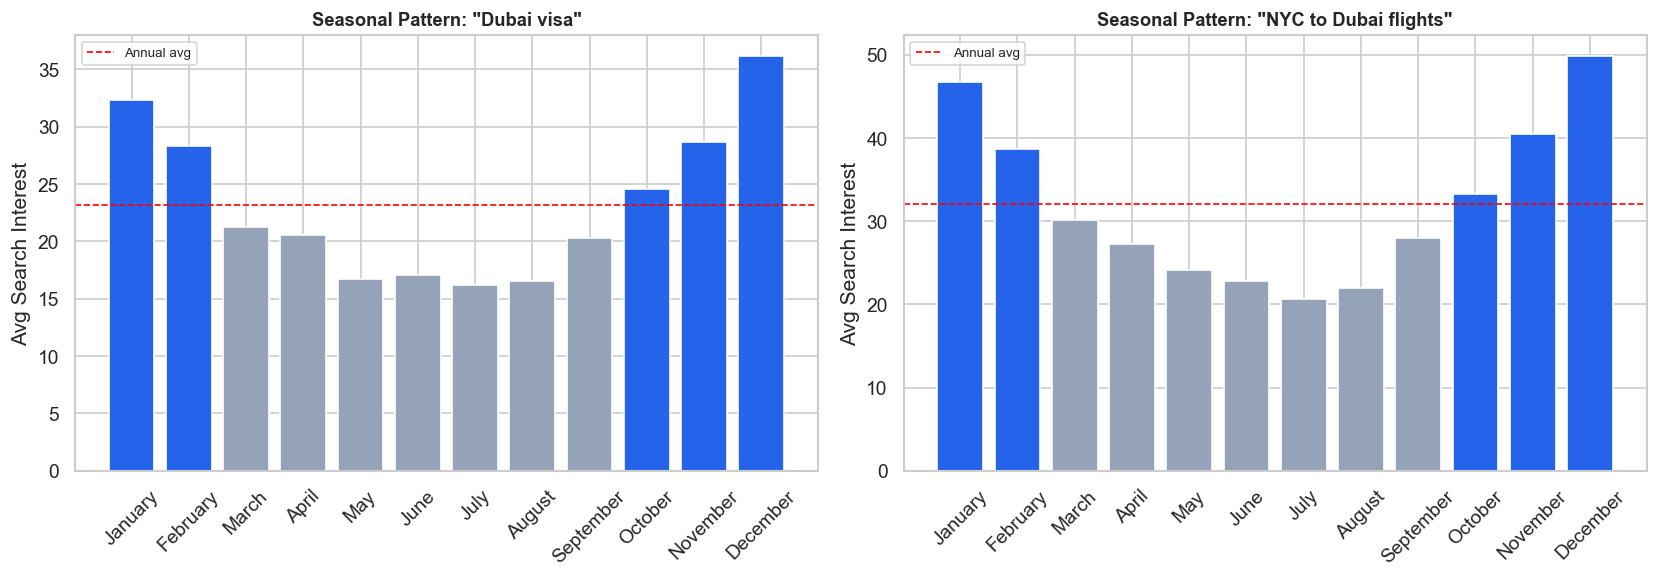

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, kw in zip(axes, ["Dubai visa", "NYC to Dubai flights"]):
    seasonal = extract_seasonal_patterns(trends_raw, kw)
    colors = ["#2563eb" if p else "#94a3b8" for p in seasonal["IS_PEAK"]]
    ax.bar(seasonal["MONTH_NAME"], seasonal["AVG_INTEREST"], color=colors)
    ax.axhline(seasonal["AVG_INTEREST"].mean(), color="red", linestyle="--",
               linewidth=1, label="Annual avg")
    ax.set_title(f'Seasonal Pattern: "{kw}"', fontsize=11, fontweight="bold")
    ax.set_ylabel("Avg Search Interest")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [37]:
playbook = generate_disruption_playbook(impact_results)
print("OTA Disruption Playbook — recommended actions by event:\n")
for _, row in playbook.iterrows():
    print(f"{'='*80}")
    print(f"Event     : {row['event_date']}")
    print(f"Impact    : {row['pct_change']:+.1f}%  ->  Severity: {row['severity'].upper()}")
    print(f"Pricing   : {row['pricing']}")
    print(f"Marketing : {row['marketing']}")
    print(f"Inventory : {row['inventory']}")
    print(f"CRM       : {row['crm']}")
    print()


NameError: name 'generate_disruption_playbook' is not defined

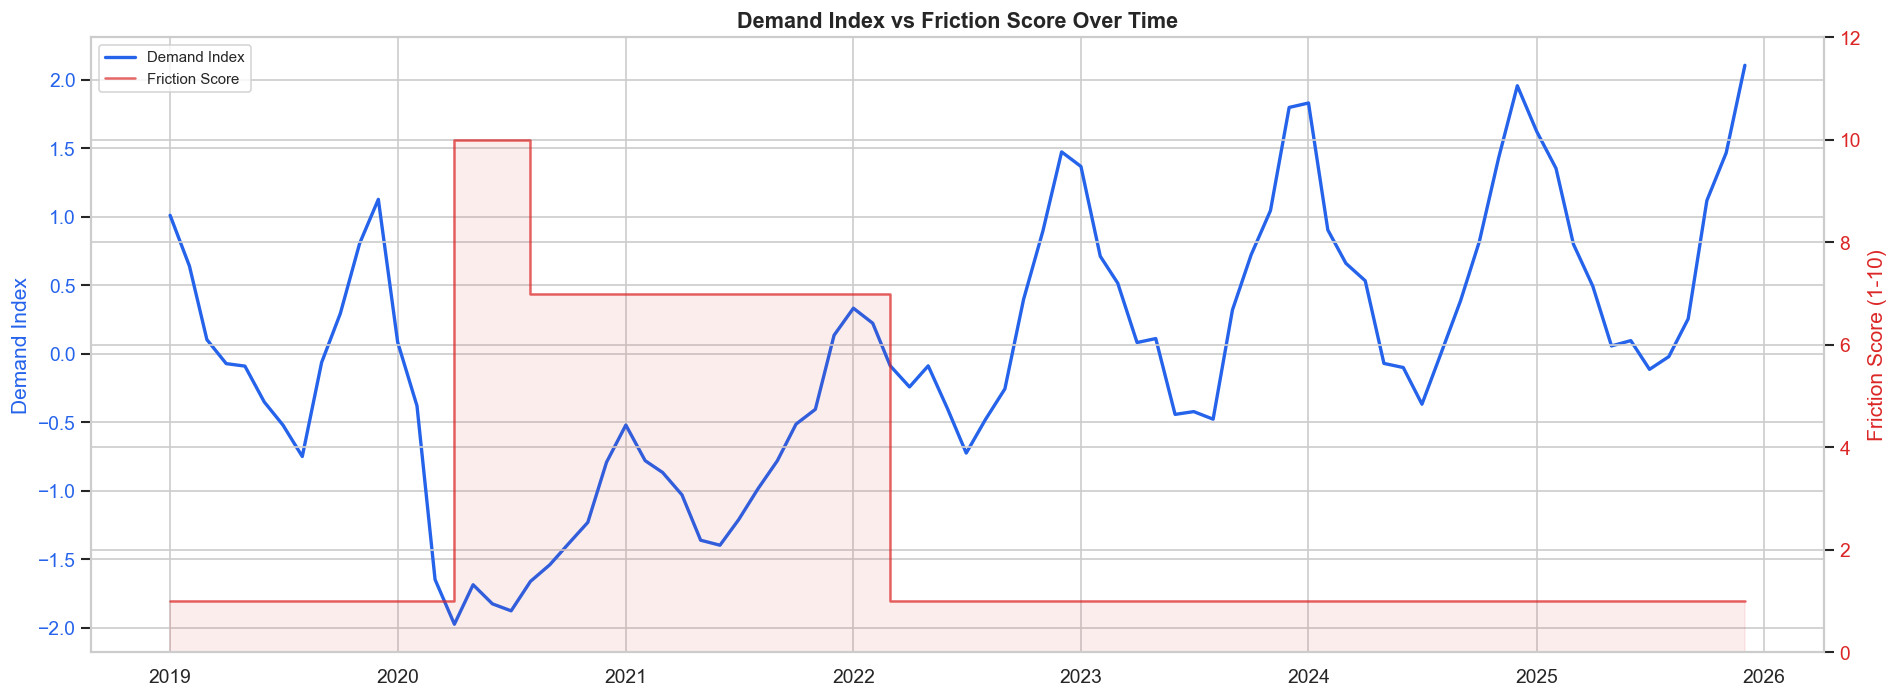

In [38]:
fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

ax1.plot(merged["date"], merged["demand_index"], color="#2563eb",
         linewidth=2, label="Demand Index")
ax1.set_ylabel("Demand Index", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")

ax2.step(merged["date"], merged["friction_score"], color="#dc2626",
         linewidth=1.5, where="post", alpha=0.7, label="Friction Score")
ax2.fill_between(merged["date"], merged["friction_score"], step="post",
                 alpha=0.08, color="#dc2626")
ax2.set_ylabel("Friction Score (1-10)", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")
ax2.set_ylim(0, 12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("Demand Index vs Friction Score Over Time", fontsize=13, fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


In [39]:
print("="*80)
print("MODULE 06 — KEY FINDINGS")
print("="*80)

covid_impact = [r for r in impact_results if "COVID" in r.get("event", "")]
if covid_impact:
    ci = covid_impact[0]
    print(f"\n1. COVID-19 TRAVEL BAN IMPACT")
    print(f"   Demand change: {ci['pct_change']:+.1f}%  |  Severity: {ci['severity']}")

covid_recovery = [r for r in recovery_results if "COVID" in r.get("event", "")]
if covid_recovery:
    cr = covid_recovery[0]
    if cr["recovery_months"]:
        print(f"   Recovery to 90% baseline: ~{cr['recovery_months']} months")
    else:
        print(f"   Recovery to 90% baseline: not yet achieved in dataset")

print(f"\n2. FRICTION <-> DEMAND CORRELATION")
print(f"   Pearson r  = {corr['pearson']}  (negative = higher friction -> lower demand)")
print(f"   Spearman p = {corr['spearman']}")

print(f"\n3. BEST & WORST POLICY REGIMES (by mean demand)")
if not regime_stats.empty:
    best = regime_stats.iloc[0]
    worst = regime_stats.iloc[-1]
    print(f"   Best : {best['regime'][:60]}  (mean={best['demand_mean']:.2f})")
    print(f"   Worst: {worst['regime'][:60]}  (mean={worst['demand_mean']:.2f})")

print(f"\n4. 'DUBAI VISA' SEARCH SPIKES")
if not visa_spikes.empty:
    print(f"   {len(visa_spikes)} spikes detected at 1.5 sigma threshold")
    if not aligned.empty:
        print(f"   {len(aligned)} spike(s) aligned with policy events (+-45 days)")
else:
    print(f"   No significant spikes detected")

print(f"\n5. OTA PLAYBOOK")
print(f"   Generated disruption playbooks for {len(playbook)} events")
print(f"   Severity distribution: {playbook['severity'].value_counts().to_dict()}")
print("\n" + "="*80)


MODULE 06 — KEY FINDINGS

2. FRICTION <-> DEMAND CORRELATION


NameError: name 'corr' is not defined